# OkLab A/B plane

This chart holds OkLab lightness at `L = 0.7` while the horizontal `A` and vertical `B` components vary. The axes show the opponent directions: green to red for `A`, and blue to yellow for `B`.

In [1]:
from pathlib import Path

import brushcue
from IPython.display import Image, display

SIZE = 720
OUTPUT_FILE = Path("/home/dito/dev/monorepo/writing/graphics/chapters/color-formats/assets/oklab-a-b-plane.png")

ctx = brushcue.Context()

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA'


In [2]:
FREEFORM_BODY = """
let point = (canvas_position - vec2<f32>(360.0, 360.0)) / 300.0;
let radius = length(point);

if radius > 1.0 {
    return vec4<f32>(1.0, 1.0, 1.0, 0.0);
}

let oklab = vec3<f32>(0.70, point.x * 0.22, -point.y * 0.22);
var rgb = linear_to_srgb(clamp(oklab_to_linear_srgb(oklab), vec3<f32>(0.0), vec3<f32>(1.0)));
let axis = min(abs(point.x), abs(point.y)) < 0.006;
let border = radius > 0.985;

if axis || border {
    rgb = vec3<f32>(0.08);
}

return vec4<f32>(rgb, 1.0);
"""

WGSL_HELPERS = """
fn linear_to_srgb(rgb: vec3<f32>) -> vec3<f32> {
    let lo = 12.92 * rgb;
    let hi = 1.055 * pow(max(rgb, vec3<f32>(0.0)), vec3<f32>(1.0 / 2.4)) - 0.055;
    return select(hi, lo, rgb <= vec3<f32>(0.0031308));
}

fn oklab_to_linear_srgb(oklab: vec3<f32>) -> vec3<f32> {
    let l = pow(oklab.x + 0.3963377774 * oklab.y + 0.2158037573 * oklab.z, 3.0);
    let m = pow(oklab.x - 0.1055613458 * oklab.y - 0.0638541728 * oklab.z, 3.0);
    let s = pow(oklab.x - 0.0894841775 * oklab.y - 1.2914855480 * oklab.z, 3.0);
    return vec3<f32>(
        4.0767416621 * l - 3.3077115913 * m + 0.2309699292 * s,
        -1.2684380046 * l + 2.6097574011 * m - 0.3413193965 * s,
        -0.0041960863 * l - 0.7034186147 * m + 1.7076147010 * s,
    );
}
"""

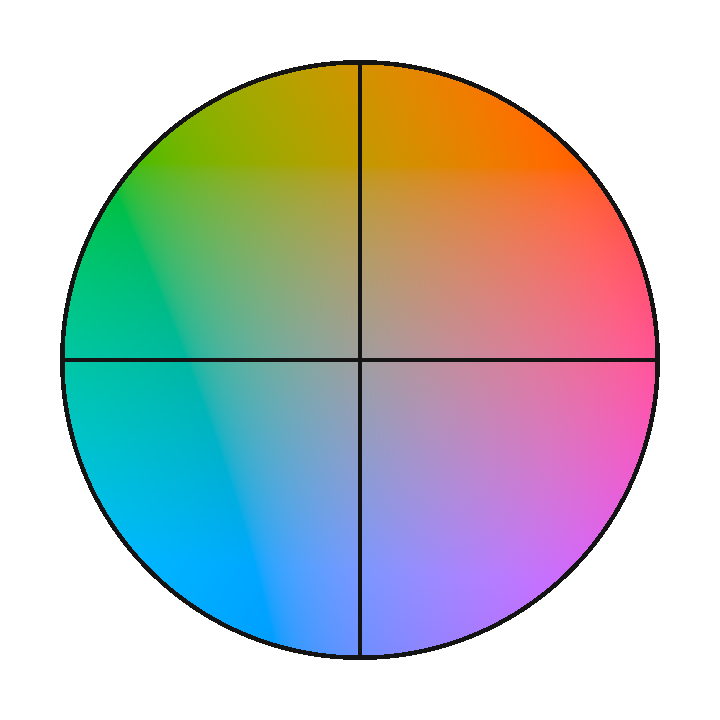

In [3]:
chart = brushcue.Composition.freeform_shader(
    FREEFORM_BODY,
    WGSL_HELPERS,
    brushcue.Bounds2f.from_x_y_width_height(0, 0, SIZE, SIZE),
    brushcue.ColorRepresentation.srgb(),
    brushcue.Dictionary.create(),
)

png = chart.execute(ctx).to_image_bytes(ctx)
OUTPUT_FILE.write_bytes(png)
display(Image(data=png))

The center is neutral gray because both `A` and `B` are zero. Moving right adds red, moving left adds green, moving up adds yellow, and moving down adds blue. The circular boundary keeps the figure focused on chroma direction; some edge colors reach the limits of sRGB and are clipped to the displayable gamut.